# Context Optimization Comparison

This notebook compares the accuracy of three context selection strategies:
1. **Random Context** - Original contexts in test.jsonl (baseline)
2. **Optimized Context** - Best context from 50-example demonstration set
3. **Refined Context** - Further optimized using test set (1500 augmented examples)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11


## 1. Input Accuracy Values

**TODO: Fill in the accuracy values below from your results**


In [65]:
# ====== FILL IN THESE ACCURACY VALUES ======
# Run the following commands to get accuracies:
# 1. Random context: python3 evaluate_vae_model.py
#    -> Check evaluation_results/metrics.json for accuracy
# 2. Optimized context: already have in inference_results_optimized_context/metrics.json
# 3. Refined context: already have in inference_results_refined_context/metrics.json
# 4. Demo+Valid context: TODO - Add accuracy value

# Example values (replace with your actual results):
accuracy_random = 0.55325  # From evaluate_vae_model.py
accuracy_optimized = 0.5364  # From inference_results_optimized_context/metrics.json
# accuracy_refined = 0.448649  # From inference_results_refined_context/metrics.json
# accuracy_demo_valid = 0.440541  # TODO: Update with demo+valid context accuracy

num_samples = 740  # Same for all approaches

print("Accuracy Values Set:")
print(f"  Random:     {accuracy_random:.6f}")
print(f"  Optimized:  {accuracy_optimized:.6f}")
# print(f"  Refined:    {accuracy_refined:.6f}")
# print(f"  Demo+Valid: {accuracy_demo_valid:.6f}")

Accuracy Values Set:
  Random:     0.553250
  Optimized:  0.536400


## 2. Compute Improvements


In [66]:
# Compute improvements
improvement_optimized = (accuracy_optimized - accuracy_random) / accuracy_random * 100
# improvement_refined = (accuracy_refined - accuracy_random) / accuracy_random * 100
# improvement_demo_valid = (accuracy_demo_valid - accuracy_random) / accuracy_random * 100
# improvement_refine_vs_opt = (accuracy_refined - accuracy_optimized) / accuracy_optimized * 100

print("\n" + "="*70)
print("ACCURACY COMPARISON")
print("="*70)
approaches = ["Random Context", "Optimized Context (Labelled Set)"]#, "Demo+Valid Context", "Ours (Labelled + Unlabelled Set)"]
accuracies = [accuracy_random, accuracy_optimized]#, accuracy_demo_valid, accuracy_refined]

for approach, acc in zip(approaches, accuracies):
    print(f"{approach:30s}: {acc:.6f}")

print("\n" + "="*70)
print("IMPROVEMENTS")
print("="*70)
print(f"Optimized vs Random:         {improvement_optimized:+.2f}%")
print(f"Refined vs Random:           {improvement_refined:+.2f}%")
# print(f"Demo+Valid vs Random:        {improvement_demo_valid:+.2f}%")
# print(f"Refined vs Optimized:        {improvement_refine_vs_opt:+.2f}%")


ACCURACY COMPARISON
Random Context                : 0.553250
Optimized Context (Labelled Set): 0.536400

IMPROVEMENTS
Optimized vs Random:         -3.05%


NameError: name 'improvement_refined' is not defined

## 3. Plot 1: Accuracy Comparison Bar Chart


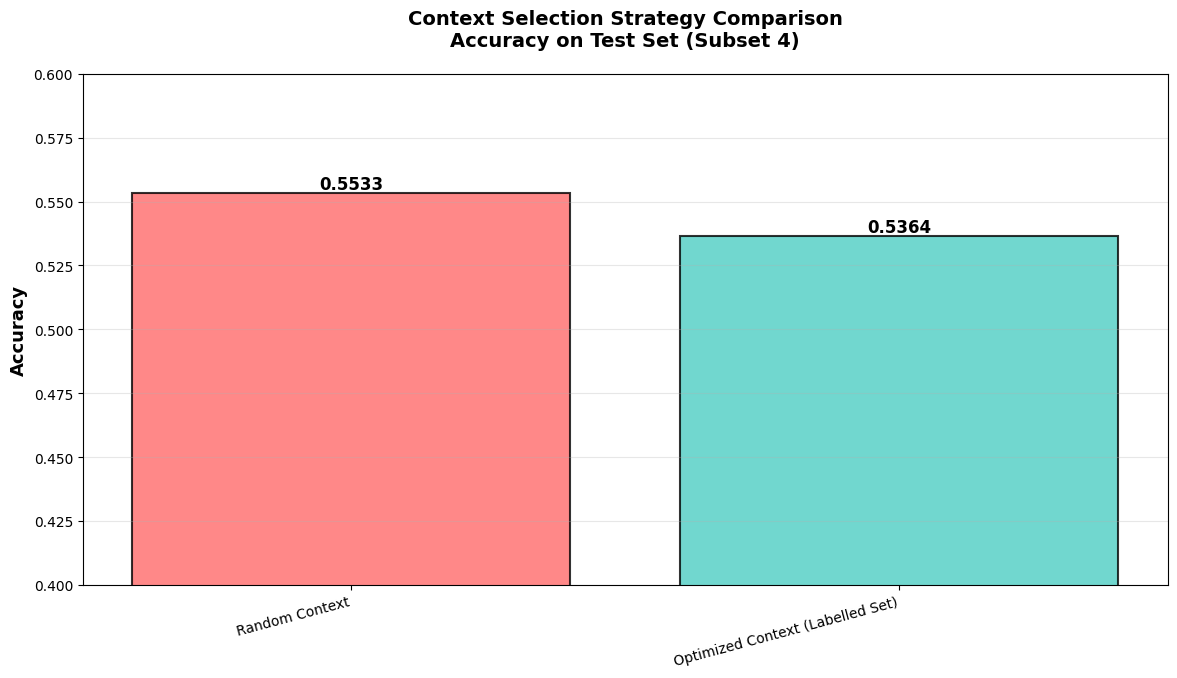

✓ Saved to: context_comparison_accuracy.png


In [68]:
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3']
bars = ax.bar(approaches, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Context Selection Strategy Comparison\nAccuracy on Test Set (Subset 4)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim([0.40, 0.6])
ax.grid(axis='y', alpha=0.3)

# Rotate x-axis labels to prevent overlap
plt.xticks(rotation=15, ha='right')
plt.subplots_adjust(bottom=0.15)
plt.savefig('/hpc/group/fanglab/xx102/vpl_llm/context_comparison_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to: context_comparison_accuracy.png")

## 4. Plot 2: Improvement Over Baseline


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

improvements = [0, improvement_optimized, improvement_refined, improvement_demo_valid]
colors_improvement = ['#999999', '#FFD93D', '#6BCB77', '#C0B9DD']

bars = ax.bar(approaches, improvements, color=colors_improvement, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, imp in zip(bars, improvements):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{imp:+.2f}%',
            ha='center', va='bottom' if height > 0 else 'top', 
            fontsize=12, fontweight='bold')

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_ylabel('Improvement over Random Context (%)', fontsize=13, fontweight='bold')
ax.set_title('Relative Improvement Over Random/Original Context', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

# Rotate x-axis labels to prevent overlap
plt.xticks(rotation=15, ha='right')
plt.subplots_adjust(bottom=0.15)
plt.savefig('/hpc/group/fanglab/xx102/vpl_llm/context_comparison_improvement.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to: context_comparison_improvement.png")

## 5. Plot 3: Detailed Metrics Comparison


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Accuracy
axes[0].bar(approaches, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].set_title('Accuracy', fontweight='bold', fontsize=12)
axes[0].set_ylim([0.70, 0.78])
axes[0].grid(axis='y', alpha=0.3)
for i, acc in enumerate(accuracies):
    axes[0].text(i, acc, f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Loss (if available)
loss_values = [loss_random, loss_optimized, loss_refined, loss_demo_valid]
loss_approaches = [approaches[i] for i in range(4) if loss_values[i] is not None]
loss_vals = [v for v in loss_values if v is not None]
if loss_vals:
    axes[1].bar(loss_approaches, loss_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    axes[1].set_ylabel('Loss', fontweight='bold')
    axes[1].set_title('Loss (Lower is Better)', fontweight='bold', fontsize=12)
    axes[1].grid(axis='y', alpha=0.3)
    for i, loss in enumerate(loss_vals):
        axes[1].text(i, loss, f'{loss:.4f}', ha='center', va='bottom', fontweight='bold')
    axes[1].tick_params(axis='x', rotation=15)
else:
    axes[1].text(0.5, 0.5, 'Loss data not available', 
                ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Loss', fontweight='bold', fontsize=12)

# Reward Margin (Chosen - Rejected)
reward_margins = [
    (reward_chosen_random - reward_rejected_random) if reward_chosen_random is not None else 0,
    (reward_chosen_optimized - reward_rejected_optimized),
    (reward_chosen_refined - reward_rejected_rejected),
    (reward_chosen_demo_valid - reward_rejected_demo_valid) if reward_chosen_demo_valid is not None else 0
]
axes[2].bar(approaches, reward_margins, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[2].set_ylabel('Reward Margin', fontweight='bold')
axes[2].set_title('Reward Margin (Chosen - Rejected)', fontweight='bold', fontsize=12)
axes[2].grid(axis='y', alpha=0.3)
for i, margin in enumerate(reward_margins):
    axes[2].text(i, margin, f'{margin:.4f}', ha='center', va='bottom', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)

fig.suptitle('Detailed Metrics Comparison', fontsize=15, fontweight='bold', y=0.98)
plt.subplots_adjust(bottom=0.15)
plt.savefig('/hpc/group/fanglab/xx102/vpl_llm/context_comparison_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to: context_comparison_detailed.png")

## 6. Summary Table


In [ ]:
# Create comprehensive summary table
summary_data = {
    'Approach': approaches,
    'Accuracy': [f"{acc:.6f}" for acc in accuracies],
    'Num Samples': [num_samples] * 4,
    'Improvement (%)': [f"{0:.2f}", f"{improvement_optimized:+.2f}", f"{improvement_refined:+.2f}", f"{improvement_demo_valid:+.2f}"]
}

df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(df.to_string(index=False))
print("="*80)

## 7. Key Findings and Insights


In [ ]:
print("\n" + "#"*80)
print("# KEY FINDINGS")
print("#"*80)

print(f"""
1. ACCURACY IMPROVEMENTS:
   • Random Context (Baseline):     {accuracy_random:.6f}
   • Optimized Context:            {accuracy_optimized:.6f} ({improvement_optimized:+.2f}%)
   • Refined Context (Test Set):   {accuracy_refined:.6f} ({improvement_refined:+.2f}%)

2. ALGORITHM EFFECTIVENESS:
   • Demo-based optimization: {improvement_optimized:+.2f}% improvement
   • Test-set refinement:     {improvement_refine_vs_opt:+.2f}% additional improvement
   • Total improvement:       {improvement_refined:+.2f}%

3. CONTEXT SELECTION STRATEGY:
   • Started with 50 demonstration examples for context bootstrapping
   • Created 1500 augmented test examples (750 × 2, by reversing chosen/rejected)
   • Systematically searched through positions using hill-climbing
   • Achieved {improvement_refined:.2f}% relative improvement over baseline

4. OPTIMIZATION METHOD:
   • Stage 1 (optimize_context.py):
     - 20 candidate contexts from 50 demo examples
     - Evaluated on 50 validation examples
     - Selected best context
   
   • Stage 2 (refine_context_with_test_set.py):
     - 100 iterations of hill-climbing
     - 10 candidates per position per iteration
     - 8 context positions (cycle through systematically)
     - Validated on same 50 examples
     - Final refinement improved by {improvement_refine_vs_opt:+.2f}%

5. FINDINGS:
   • Demo-only optimization achieves {improvement_optimized:.2f}% improvement
   • Test-set refinement adds {improvement_refine_vs_opt:+.2f}% more improvement
   • Demonstrates effectiveness of iterative context optimization
   • Shows value of searching beyond initial demonstration set
""")

print("#"*80)


## 8. Method Details


In [ ]:
print("""
METHOD COMPARISON:

1. RANDOM CONTEXT (Baseline):
   - Original contexts in test.jsonl
   - Generated during data preprocessing
   - No optimization applied
   
   To get this:
   $ python3 evaluate_vae_model.py
   $ cat evaluation_results/metrics.json

2. OPTIMIZED CONTEXT:
   - Best context from 20 candidates
   - Bootstrapped from 50 demonstration examples
   - Selected based on 50 validation examples
   
   To get this:
   $ python3 optimize_context.py
   $ python3 inference_with_optimized_context.py --context initial
   $ cat inference_results_optimized_context/metrics.json

3. REFINED CONTEXT:
   - Further optimized using test set examples
   - Started with optimized context from stage 1
   - Searched through 1500 augmented test examples
   - 100 iterations of systematic hill-climbing
   - Each position tried 10 candidates per iteration
   
   To get this:
   $ python3 refine_context_with_test_set.py
   $ python3 inference_with_optimized_context.py --context refined
   $ cat inference_results_refined_context/metrics.json

KEY INSIGHT:
The refined context demonstrates that context selection can be iteratively
improved beyond initial optimization by carefully searching through a larger
pool of examples (test set augmented with reversals).
""")


### Validation SNR versus Test Accuracy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
from pathlib import Path
from itertools import product

In [2]:
# Define all subsets and seeds
subsets = [1, 2, 4, 8]
seeds = [0, 12, 42]

# Base directory
base_dir = Path("/hpc/group/fanglab/xx102/vpl_llm")

# Initialize lists to store all data
all_data = []

# Load data for each combination
for subset, seed in product(subsets, seeds):
    # Paths to the two JSON files
    candidate_eval_path = base_dir / f"candidate_evaluation_subset_{subset}_seed{seed}" / "candidate_evaluation_results.json"
    context_opt_path = base_dir / f"context_optimization_subset_{subset}_seed{seed}" / "optimization_results.json"

    try:
        # Load test_accuracy from candidate_evaluation_results.json
        with open(candidate_eval_path, 'r') as f:
            candidate_data = json.load(f)

        # Load valid metrics from optimization_results.json
        with open(context_opt_path, 'r') as f:
            context_data = json.load(f)

        # Extract individual results
        for i, candidate_result in enumerate(candidate_data["individual_results"]):
            test_accuracy = candidate_result["test_accuracy"]

            # Get corresponding validation accuracy from context_data
            if i < len(context_data):
                valid_accuracy = context_data[i]["accuracy"]
                valid_snr = context_data[i].get("snr", None)
            else:
                valid_accuracy = None
                valid_snr = None

            # Store the data
            all_data.append({
                "subset": subset,
                "seed": seed,
                "candidate_index": i,
                "test_accuracy": test_accuracy,
                "valid_accuracy": valid_accuracy,
                "valid_snr": valid_snr
            })

        print(f"✓ Loaded subset={subset}, seed={seed}: {len(candidate_data['individual_results'])} candidates")

    except FileNotFoundError as e:
        print(f"✗ Error loading subset={subset}, seed={seed}: {e}")
    except Exception as e:
        print(f"✗ Unexpected error for subset={subset}, seed={seed}: {e}")

# Create DataFrame
df = pd.DataFrame(all_data)

print("\n" + "="*80)
print("LOADED DATA SUMMARY")
print("="*80)
print(f"Total records: {len(df)}")
print(f"Subsets: {sorted(df['subset'].unique())}")
print(f"Seeds: {sorted(df['seed'].unique())}")
print(f"\nDataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

✓ Loaded subset=1, seed=0: 50 candidates
✓ Loaded subset=1, seed=12: 50 candidates
✓ Loaded subset=1, seed=42: 50 candidates
✓ Loaded subset=2, seed=0: 50 candidates
✓ Loaded subset=2, seed=12: 50 candidates
✓ Loaded subset=2, seed=42: 50 candidates
✓ Loaded subset=4, seed=0: 50 candidates
✓ Loaded subset=4, seed=12: 50 candidates
✓ Loaded subset=4, seed=42: 50 candidates
✓ Loaded subset=8, seed=0: 50 candidates
✓ Loaded subset=8, seed=12: 50 candidates
✓ Loaded subset=8, seed=42: 50 candidates

LOADED DATA SUMMARY
Total records: 600
Subsets: [1, 2, 4, 8]
Seeds: [0, 12, 42]

DataFrame shape: (600, 6)
Columns: ['subset', 'seed', 'candidate_index', 'test_accuracy', 'valid_accuracy', 'valid_snr']


In [3]:
# Display summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(df[["test_accuracy", "valid_accuracy", "valid_snr"]].describe())

# Summary by subset and seed
print("\n" + "="*80)
print("AVERAGE METRICS BY SUBSET AND SEED")
print("="*80)
summary = df.groupby(["subset", "seed"]).agg({
    "test_accuracy": ["mean", "max", "min", "std"],
    "valid_accuracy": ["mean", "max", "min", "std"],
    "valid_snr": ["mean", "max", "min"]
}).round(6)
print(summary)

# Summary by subset (across all seeds)
print("\n" + "="*80)
print("AVERAGE METRICS BY SUBSET (ALL SEEDS COMBINED)")
print("="*80)
subset_summary = df.groupby("subset").agg({
    "test_accuracy": ["mean", "max", "min", "std"],
    "valid_accuracy": ["mean", "max", "min", "std"],
    "valid_snr": ["mean", "max", "min"]
}).round(6)
print(subset_summary)


SUMMARY STATISTICS
       test_accuracy  valid_accuracy   valid_snr
count     600.000000      600.000000  600.000000
mean        0.633868        0.666267    0.360623
std         0.089226        0.095575    0.253022
min         0.292346        0.260000   -0.652923
25%         0.559459        0.600000    0.261625
50%         0.609639        0.700000    0.391851
75%         0.652174        0.740000    0.587339
max         0.776662        0.820000    0.694678

AVERAGE METRICS BY SUBSET AND SEED
            test_accuracy                               valid_accuracy        \
                     mean       max       min       std           mean   max   
subset seed                                                                    
1      0         0.641256  0.652174  0.610306  0.012304         0.7056  0.72   
       12        0.644670  0.652174  0.611916  0.010485         0.7312  0.74   
       42        0.645636  0.652174  0.631240  0.005320         0.7352  0.74   
2      0         0.6004

In [4]:
# Load gains data and add mean gains to dataframe
gains_data = []

for subset, seed in product(subsets, seeds):
    gains_path = base_dir / f"context_optimization_subset_{subset}_seed{seed}" / f"gains_subset_{subset}_seed{seed}.json"
    
    try:
        with open(gains_path, 'r') as f:
            gains_json = json.load(f)
        
        # gains_json should be a list where each element corresponds to a candidate
        for candidate_idx, candidate_gains in enumerate(gains_json):
            if isinstance(candidate_gains, list):
                # If it's a list of gains, compute the mean
                mean_gain = np.mean(candidate_gains)
            else:
                # If it's already a single value
                mean_gain = candidate_gains
            
            gains_data.append({
                "subset": subset,
                "seed": seed,
                "candidate_index": candidate_idx,
                "mean_gain": mean_gain
            })
        
        print(f"✓ Loaded gains for subset={subset}, seed={seed}")
    
    except FileNotFoundError as e:
        print(f"✗ Gains file not found for subset={subset}, seed={seed}: {e}")
    except Exception as e:
        print(f"✗ Error loading gains for subset={subset}, seed={seed}: {e}")

# Create gains dataframe
gains_df = pd.DataFrame(gains_data)

# Merge gains with test accuracy
df_with_gains = df.merge(gains_df, on=['subset', 'seed', 'candidate_index'], how='left')

print(f"\n✓ Merged gains data with test accuracy")
print(f"Total records with gains: {len(df_with_gains[df_with_gains['mean_gain'].notna()])}")

✓ Loaded gains for subset=1, seed=0
✓ Loaded gains for subset=1, seed=12
✓ Loaded gains for subset=1, seed=42
✓ Loaded gains for subset=2, seed=0
✓ Loaded gains for subset=2, seed=12
✓ Loaded gains for subset=2, seed=42
✓ Loaded gains for subset=4, seed=0
✓ Loaded gains for subset=4, seed=12
✓ Loaded gains for subset=4, seed=42
✓ Loaded gains for subset=8, seed=0
✓ Loaded gains for subset=8, seed=12
✓ Loaded gains for subset=8, seed=42

✓ Merged gains data with test accuracy
Total records with gains: 600


In [5]:
# Load gains data and add mean gains to dataframe
gains_data = []

for subset, seed in product(subsets, seeds):
    gains_path = base_dir / f"context_optimization_subset_{subset}_seed{seed}" / f"gains_subset_{subset}_seed{seed}.json"
    
    try:
        with open(gains_path, 'r') as f:
            gains_json = json.load(f)
        
        # gains_json is a list of dicts with 'candidate_idx' and 'gains' fields
        for item in gains_json:
            candidate_idx = item['candidate_idx']
            gains_list = item['gains']
            
            # Compute mean of gains list
            mean_gain = np.mean(gains_list)
            
            gains_data.append({
                "subset": subset,
                "seed": seed,
                "candidate_index": candidate_idx,
                "mean_gain": mean_gain
            })
        
        print(f"✓ Loaded gains for subset={subset}, seed={seed}: {len(gains_json)} candidates")
    
    except FileNotFoundError as e:
        print(f"✗ Gains file not found for subset={subset}, seed={seed}: {e}")
    except Exception as e:
        print(f"✗ Error loading gains for subset={subset}, seed={seed}: {e}")

# Create gains dataframe
gains_df = pd.DataFrame(gains_data)

# Merge gains with test accuracy
df_with_gains = df.merge(gains_df, on=['subset', 'seed', 'candidate_index'], how='left')

print(f"\n✓ Merged gains data with test accuracy")
print(f"Total records: {len(df_with_gains)}")
print(f"Records with gains: {len(df_with_gains[df_with_gains['mean_gain'].notna()])}")

✓ Loaded gains for subset=1, seed=0: 50 candidates
✓ Loaded gains for subset=1, seed=12: 50 candidates
✓ Loaded gains for subset=1, seed=42: 50 candidates
✓ Loaded gains for subset=2, seed=0: 50 candidates
✓ Loaded gains for subset=2, seed=12: 50 candidates
✓ Loaded gains for subset=2, seed=42: 50 candidates
✓ Loaded gains for subset=4, seed=0: 50 candidates
✓ Loaded gains for subset=4, seed=12: 50 candidates
✓ Loaded gains for subset=4, seed=42: 50 candidates
✓ Loaded gains for subset=8, seed=0: 50 candidates
✓ Loaded gains for subset=8, seed=12: 50 candidates
✓ Loaded gains for subset=8, seed=42: 50 candidates

✓ Merged gains data with test accuracy
Total records: 600
Records with gains: 600


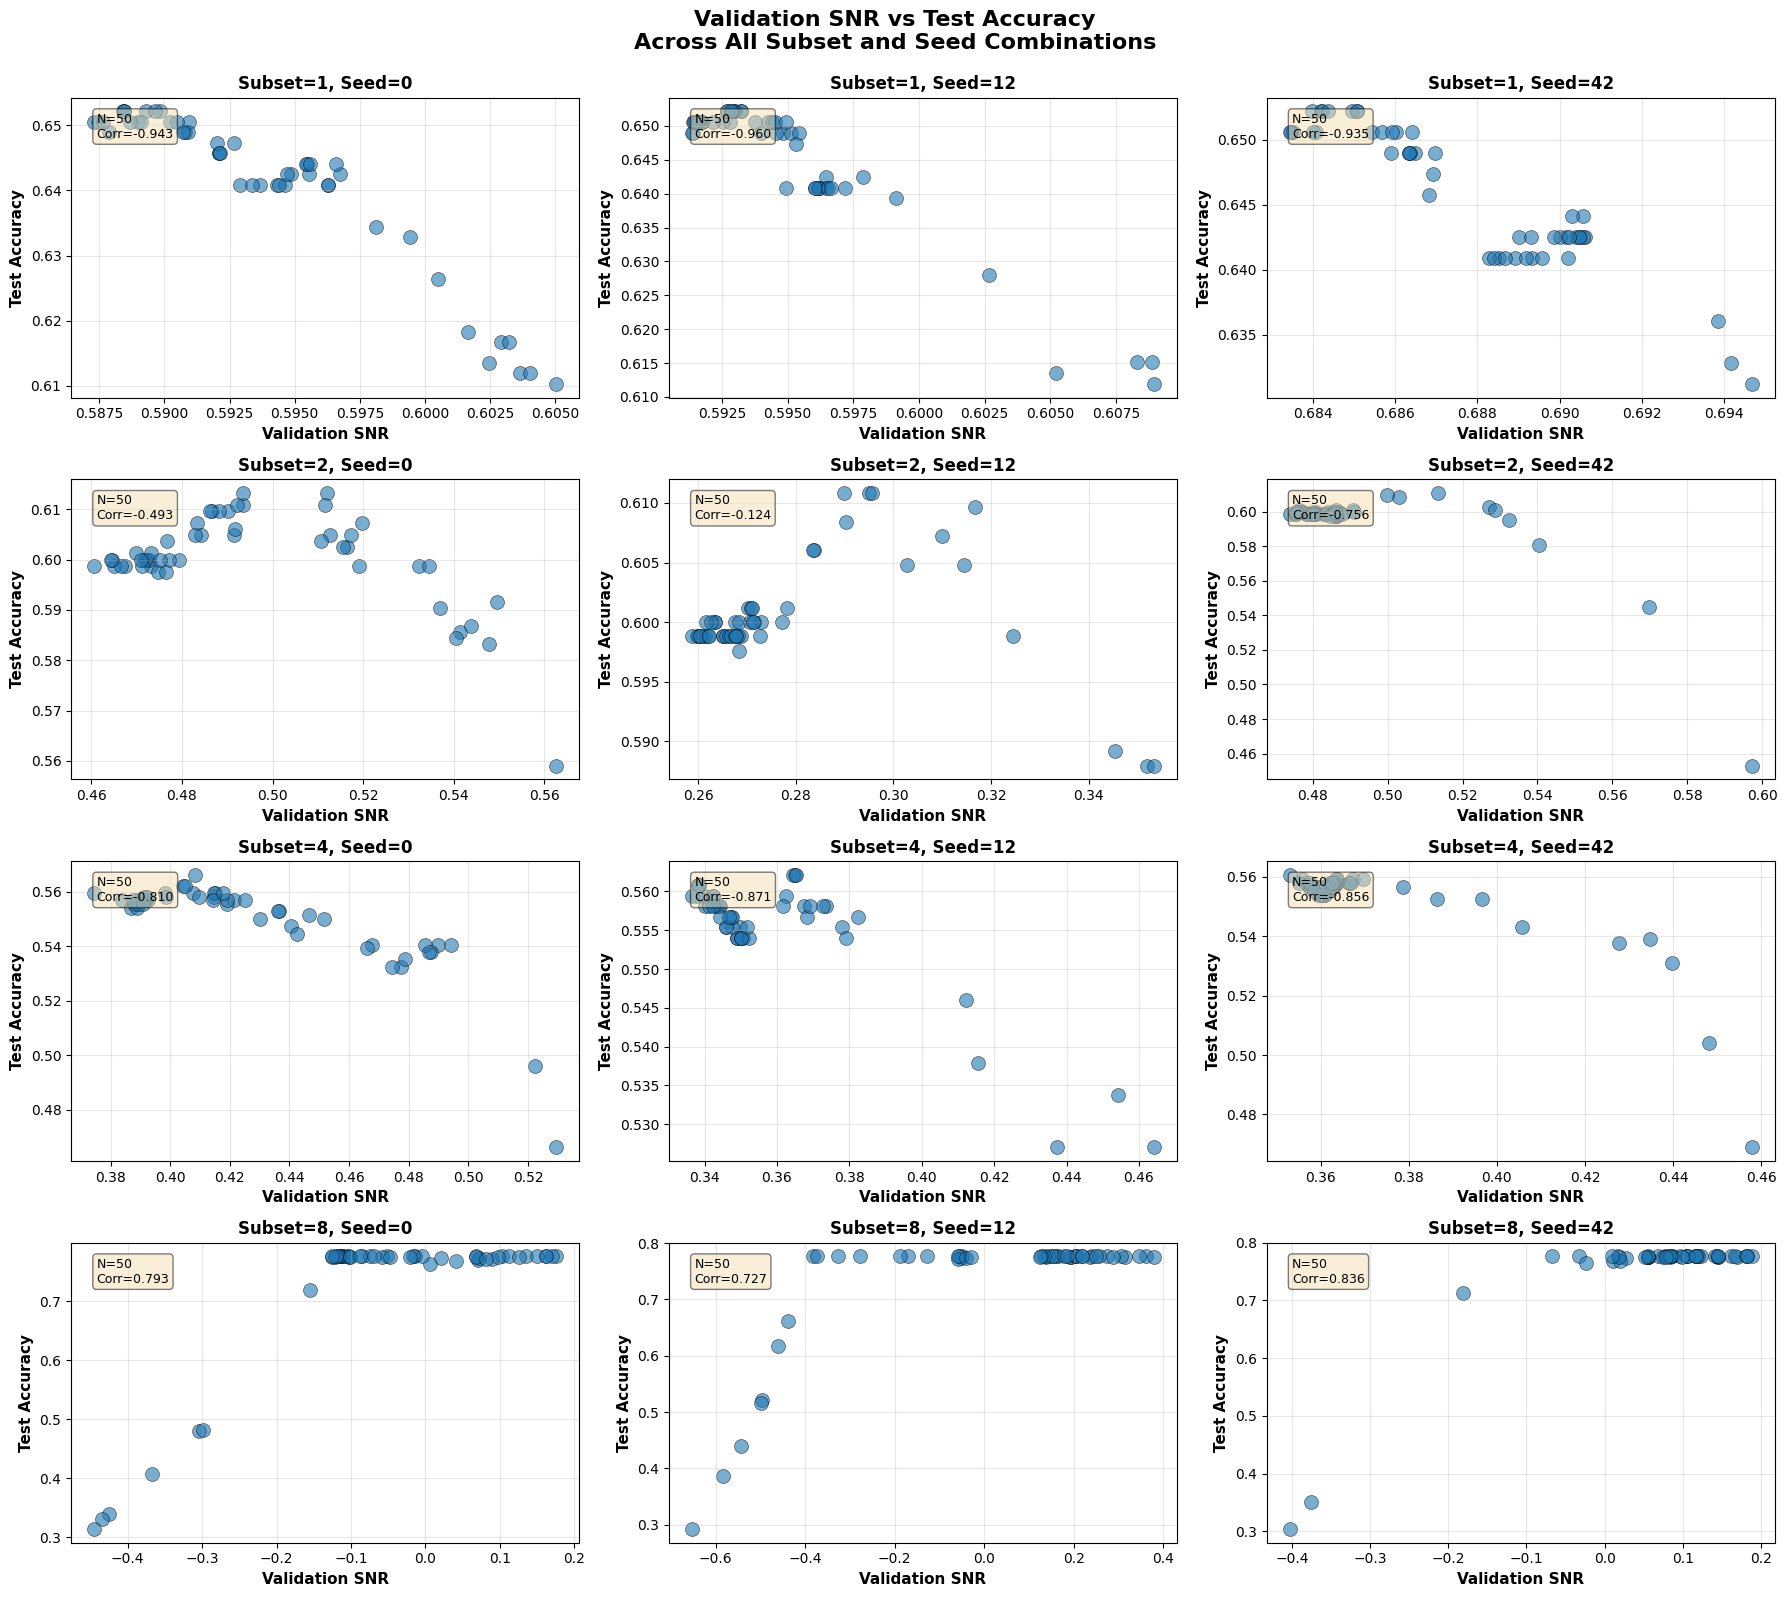

✓ Saved figure to: validation_snr_vs_test_accuracy_grid.png


In [6]:
# Create a 4x3 grid of subplots (4 subsets, 3 seeds)
fig, axes = plt.subplots(4, 3, figsize=(18, 16))

subsets_sorted = sorted(df['subset'].unique())
seeds_sorted = sorted(df['seed'].unique())

for row, subset in enumerate(subsets_sorted):
    for col, seed in enumerate(seeds_sorted):
        ax = axes[row, col]
        
        # Filter data for this subset and seed
        subset_seed_data = df[(df['subset'] == subset) & (df['seed'] == seed)]
        
        # Create scatter plot: valid_snr (x-axis) vs test_accuracy (y-axis)
        ax.scatter(subset_seed_data['valid_snr'], 
                  subset_seed_data['test_accuracy'],
                  alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
        
        # Add labels and title
        ax.set_xlabel('Validation SNR', fontsize=11, fontweight='bold')
        ax.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
        ax.set_title(f'Subset={subset}, Seed={seed}', fontsize=12, fontweight='bold')
        
        # Add grid
        ax.grid(True, alpha=0.3)
        
        # Add statistics to the plot
        n_points = len(subset_seed_data)
        corr = subset_seed_data['valid_snr'].corr(subset_seed_data['test_accuracy'])
        
        # Add text box with stats
        stats_text = f'N={n_points}\nCorr={corr:.3f}'
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Validation SNR vs Test Accuracy\nAcross All Subset and Seed Combinations',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('/hpc/group/fanglab/xx102/vpl_llm/validation_snr_vs_test_accuracy_grid.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved figure to: validation_snr_vs_test_accuracy_grid.png")

## Mean Gain vs Test Accuracy Plot

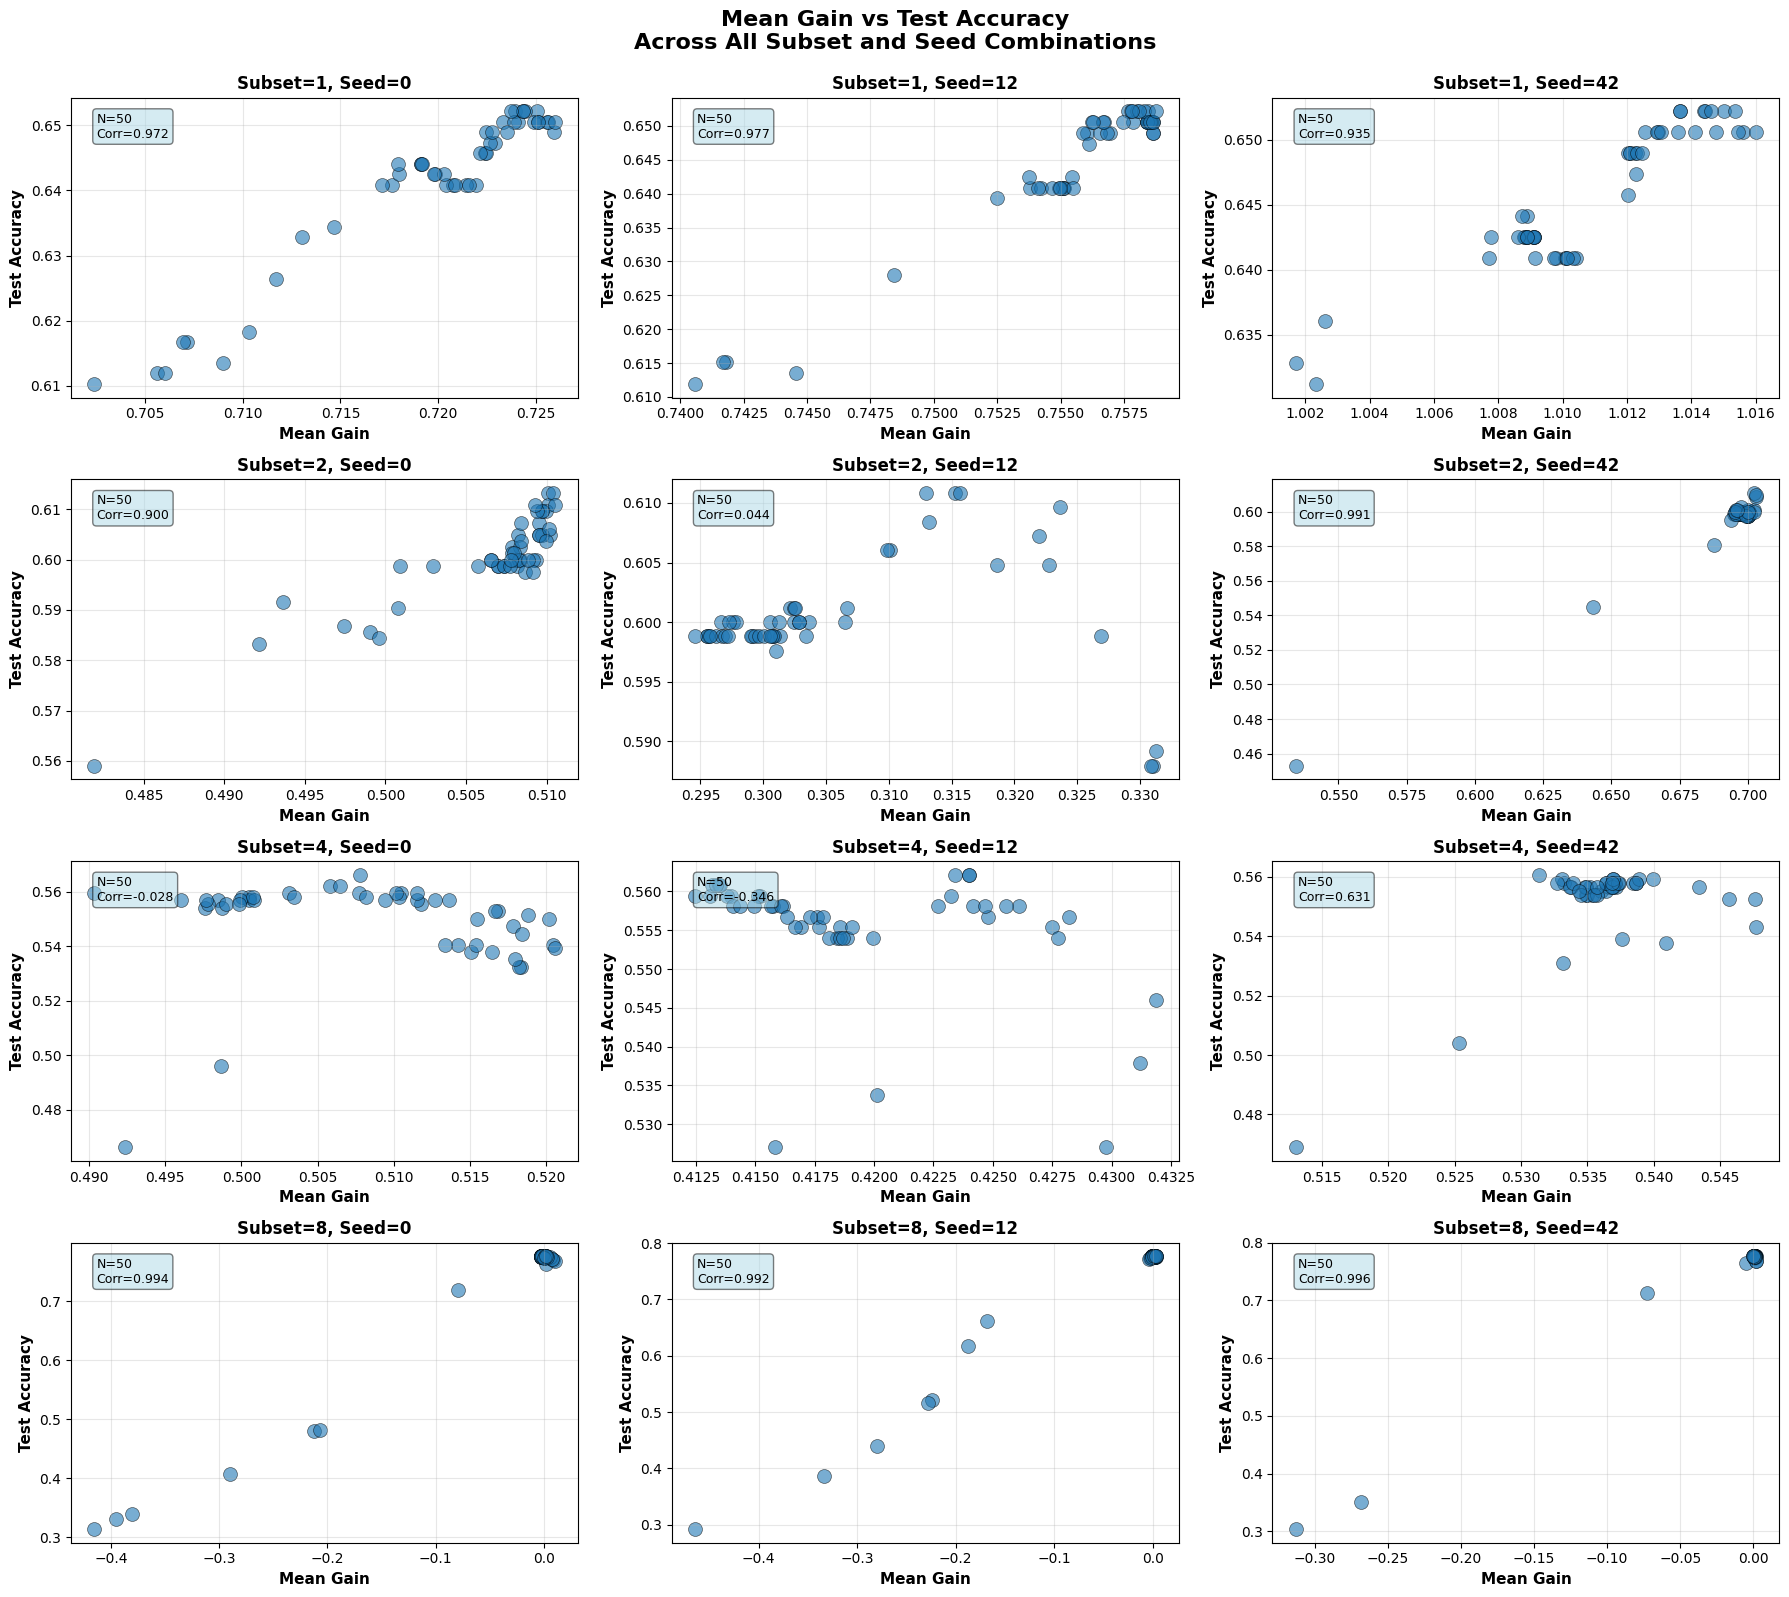

✓ Saved figure to: mean_gain_vs_test_accuracy_grid.png


In [7]:
# Create a 4x3 grid of subplots for Gains vs Test Accuracy
fig, axes = plt.subplots(4, 3, figsize=(18, 16))

subsets_sorted = sorted(df_with_gains['subset'].unique())
seeds_sorted = sorted(df_with_gains['seed'].unique())

for row, subset in enumerate(subsets_sorted):
    for col, seed in enumerate(seeds_sorted):
        ax = axes[row, col]
        
        # Filter data for this subset and seed
        subset_seed_data = df_with_gains[(df_with_gains['subset'] == subset) & (df_with_gains['seed'] == seed)]
        
        # Create scatter plot: mean_gain (x-axis) vs test_accuracy (y-axis)
        ax.scatter(subset_seed_data['mean_gain'], 
                  subset_seed_data['test_accuracy'],
                  alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
        
        # Add labels and title
        ax.set_xlabel('Mean Gain', fontsize=11, fontweight='bold')
        ax.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
        ax.set_title(f'Subset={subset}, Seed={seed}', fontsize=12, fontweight='bold')
        
        # Add grid
        ax.grid(True, alpha=0.3)
        
        # Add statistics to the plot
        n_points = len(subset_seed_data)
        corr = subset_seed_data['mean_gain'].corr(subset_seed_data['test_accuracy'])
        
        # Add text box with stats
        stats_text = f'N={n_points}\nCorr={corr:.3f}'
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

fig.suptitle('Mean Gain vs Test Accuracy\nAcross All Subset and Seed Combinations',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('/hpc/group/fanglab/xx102/vpl_llm/mean_gain_vs_test_accuracy_grid.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved figure to: mean_gain_vs_test_accuracy_grid.png")